# B142 Data Integration Project

## Project Title
Big Data Integration and Analysis of Brazilian E-Commerce Transactions Using Apache Spark

## Dataset
Brazilian E-Commerce Public Dataset by Olist from Kaggle.

## Objective
The objective of this project is to design a simple big data pipeline using Apache Spark. The project loads multiple CSV files, cleans the data, integrates the tables, stores the processed data in Parquet format, and uses Spark SQL to generate business insights.

In [116]:
!pip install pyspark

In [117]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
.appName("Olist Data Integration Project") \
    .getOrCreate()
spark

## 1. Data Ingestion

In this section, the raw CSV files are loaded into Apache Spark DataFrames. Five related datasets are used: customers, orders, order items, payments and products. These files represent different parts of the e-commerce transaction process and will later be integrated using common keys such as `customer_id`, `order_id` and `product_id`.

In [118]:
customers = spark.read.csv("/content/olist_customers_dataset.csv", header=True, inferSchema=True)
orders = spark.read.csv("/content/olist_orders_dataset.csv", header=True, inferSchema=True)
order_items = spark.read.csv("/content/olist_order_items_dataset.csv", header=True, inferSchema=True)
payments = spark.read.csv("/content/olist_order_payments_dataset.csv", header=True, inferSchema=True)
products = spark.read.csv("/content/olist_products_dataset.csv", header=True, inferSchema=True)

## 2. Initial Data Exploration

After loading the datasets, the number of records in each DataFrame is checked. This helps to understand the size of each dataset before cleaning and integration begins.

In [119]:
print("Customers:", customers.count())
print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Payments:", payments.count())
print("Products:", products.count())

Customers: 99441
Orders: 99441
Order Items: 112650
Payments: 103886
Products: 32951


## 3. Data Preview

here the first five rows of each dataset are displayed so has to understand the structure and content of the data before applying preprocessing steps.

In [120]:
customers.show(5)
orders.show(5)
order_items.show(5)
payments.show(5)
products.show(5)


+--------------------+--------------------+------------------------+--------------------+--------------+
|         customer_id|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|
+--------------------+--------------------+------------------------+--------------------+--------------+
|06b8999e2fba1a1fb...|861eff4711a542e4b...|                   14409|              franca|            SP|
|18955e83d337fd6b2...|290c77bc529b7ac93...|                    9790|sao bernardo do c...|            SP|
|4e7b3e00288586ebd...|060e732b5b29e8181...|                    1151|           sao paulo|            SP|
|b2b6027bc5c5109e5...|259dac757896d24d7...|                    8775|     mogi das cruzes|            SP|
|4f2d8ab171c80ec83...|345ecd01c38d18a90...|                   13056|            campinas|            SP|
+--------------------+--------------------+------------------------+--------------------+--------------+
only showing top 5 rows
+--------------------+---------

## 4. Schema Inspection process.

Here the schema of each DataFrame will be inspected to identify column names, data types and nullable fields. This step is very important before joining the datasets because the correct key columns must be identified.

In [121]:
customers.printSchema()
orders.printSchema()
order_items.printSchema()
payments.printSchema()
products.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)

root
 |

## 5. Column Verification process

Here the column names are showed to confirm the available fields in each dataset. This helps to identify the columns needed for data integration, such as `customer_id`, `order_id` and `product_id`.

In [122]:
print("Customers columns:", customers.columns)
print("Orders columns:", orders.columns)
print("Order Items columns:", order_items.columns)
print("Payments columns:", payments.columns)
print("Products columns:", products.columns)

Customers columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Orders columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Order Items columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Payments columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
Products columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


## 6. Data Cleaning and Preprocessing

This section performs basic data cleaning before integration. The cleaning process includes checking missing values, removing duplicate records and handling incomplete product category values. Simple Spark DataFrame operations are used to keep the project understandable and suitable has a junior data engineering as started on my assesment brief

In [123]:
from pyspark.sql.functions import col, sum
def check_missing_values(df, name):
    print("Missing values in", name)
    df.select([sum(col(c).isNull().cast("int")).alias(c)for c in df.columns]).show()

In [124]:
check_missing_values(customers, "Customers")
check_missing_values(orders, "Orders")
check_missing_values(order_items, "Order Items")
check_missing_values(payments, "Payments")
check_missing_values(products, "Products")

Missing values in Customers
+-----------+------------------+------------------------+-------------+--------------+
|customer_id|customer_unique_id|customer_zip_code_prefix|customer_city|customer_state|
+-----------+------------------+------------------------+-------------+--------------+
|          0|                 0|                       0|            0|             0|
+-----------+------------------+------------------------+-------------+--------------+

Missing values in Orders
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|order_id|customer_id|order_status|order_purchase_timestamp|order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|      

## 7. Handling Duplicates and Missing Values

Duplicate records are removed from all datasets. Missing values are handled using simple methods. Rows with missing key fields are removed because these fields are required for joining the datasets. Missing product categories are filled with `unknown` so that the records can still be used in our analysis.

# here we will remove duplicate records


In [125]:
customers = customers.dropDuplicates()
orders = orders.dropDuplicates()
order_items = order_items.dropDuplicates()
payments = payments.dropDuplicates()
products = products.dropDuplicates()

# Here we remove rows with missing important join keys

In [126]:
customers = customers.dropna(subset=["customer_id"])
orders = orders.dropna(subset=["order_id", "customer_id"])
order_items = order_items.dropna(subset=["order_id", "product_id"])
payments = payments.dropna(subset=["order_id"])
products = products.dropna(subset=["product_id"])

# Fill missing product category values

In [127]:
products = products.fillna({"product_category_name": "unknown"})

# Check row counts after cleaning here

In [128]:
print("Customers after cleaning:", customers.count())
print("Orders after cleaning:", orders.count())
print("Order Items after cleaning:", order_items.count())
print("Payments after cleaning:", payments.count())
print("Products after cleaning:", products.count())

Customers after cleaning: 99441
Orders after cleaning: 99441
Order Items after cleaning: 112650
Payments after cleaning: 103886
Products after cleaning: 32951


## 8. Data Integration

In this section, the cleaned datasets are integrated using common key columns. The `orders` table is joined together with `customers` using `customer_id`. The result is then joined together with `order_items` and `payments` using `order_id`.  and then Finally, the products table is joined using `product_id`.
 So , This creates one integrated dataset for analysis.

# Then here we join orders with customers

In [129]:
orders_customers = orders.join(customers,on="customer_id",how="inner")
orders_customers.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------+--------------+
|         customer_id|            order_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|  customer_unique_id|customer_zip_code_prefix| customer_city|customer_state|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+--------------+--------------+
|12ae89712aa5a178c...|6f6665c1d76e55561...|   delivered|     2017-02-23 08:03:00|2017-02-23 08:15:17|         2017-02-23 09:10:22|          2017-03-02 09:23:07|          2017-04-03 00:00:00|3b9e2937d

In [130]:
orders_items = orders_customers.join( order_items, on="order_id",how="inner")
orders_items.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+---------------+--------------+-------------+--------------------+--------------------+-------------------+-----+-------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|  customer_unique_id|customer_zip_code_prefix|  customer_city|customer_state|order_item_id|          product_id|           seller_id|shipping_limit_date|price|freight_value|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+---------------+--------------+-----

In [131]:
orders_payments = orders_items.join(payments,on="order_id",how="inner")
orders_payments.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+---------------+--------------+-------------+--------------------+--------------------+-------------------+-----+-------------+------------------+------------+--------------------+-------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|  customer_unique_id|customer_zip_code_prefix|  customer_city|customer_state|order_item_id|          product_id|           seller_id|shipping_limit_date|price|freight_value|payment_sequential|payment_type|payment_installments|payment_value|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+--------

In [132]:
final_df = orders_payments.join(products,on="product_id",how="inner")
final_df.show(5)

+--------------------+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------+------------------------+---------------+--------------+-------------+--------------------+-------------------+-----+-------------+------------------+------------+--------------------+-------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|          product_id|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|  customer_unique_id|customer_zip_code_prefix|  customer_city|customer_state|order_item_id|           seller_id|shipping_limit_date|price|freight_value|payment_sequential|payment_type|payment_installm

In [133]:
print("Final integrated dataset rows:", final_df.count())
print("Final integrated dataset columns:", len(final_df.columns))

Final integrated dataset rows: 117601
Final integrated dataset columns: 30


## 9. Verify the Integrated Dataset

Here in this section we verifies the number of records after each join operation. This helps identify any data integration issues before we proceeds to the analysis.

In [134]:
print("Customers:", customers.count())
print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Payments:", payments.count())
print("Products:", products.count())

print("Orders + Customers:", orders_customers.count())
print("Orders + Items:", orders_items.count())
print("Orders + Payments:", orders_payments.count())

Customers: 99441
Orders: 99441
Order Items: 112650
Payments: 103886
Products: 32951
Orders + Customers: 99441
Orders + Items: 112650
Orders + Payments: 117601


## We are Reloading Dataset again

The initial uploaded files produced very low join matches, which suggests that the uploaded files may not be complete or properly aligned. So to ensure consistency, the dataset is now downloaded directly from Kaggle inside Google Colab using the command below

In [135]:
!pip install kagglehub

In [136]:
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Dataset path:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset path: /kaggle/input/brazilian-ecommerce


In [137]:
customers = spark.read.csv(path + "/olist_customers_dataset.csv", header=True, inferSchema=True)
orders = spark.read.csv(path + "/olist_orders_dataset.csv", header=True, inferSchema=True)
order_items = spark.read.csv(path + "/olist_order_items_dataset.csv", header=True, inferSchema=True)
payments = spark.read.csv(path + "/olist_order_payments_dataset.csv", header=True, inferSchema=True)
products = spark.read.csv(path + "/olist_products_dataset.csv", header=True, inferSchema=True)

In [138]:
print("Customers:", customers.count())
print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Payments:", payments.count())
print("Products:", products.count())

Customers: 99441
Orders: 99441
Order Items: 112650
Payments: 103886
Products: 32951


# 6. Data Cleaning and Preprocessing

Before integrating the datasets, data quality checks are performed. This includes identifying missing values, removing duplicate records, and handling incomplete product information again. So these preprocessing steps improve the reliability of the final integrated dataset.

In [139]:
from pyspark.sql.functions import col, sum

def check_missing(df, name):
    print(f"\n{name}")
    df.select([sum(col(c).isNull().cast("int")).alias(c)for c in df.columns]).show()

check_missing(customers, "Customers")
check_missing(orders, "Orders")
check_missing(order_items, "Order Items")
check_missing(payments, "Payments")
check_missing(products, "Products")


Customers
+-----------+------------------+------------------------+-------------+--------------+
|customer_id|customer_unique_id|customer_zip_code_prefix|customer_city|customer_state|
+-----------+------------------+------------------------+-------------+--------------+
|          0|                 0|                       0|            0|             0|
+-----------+------------------+------------------------+-------------+--------------+


Orders
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|order_id|customer_id|order_status|order_purchase_timestamp|order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|       0|          0|           0|      

## Removing Duplicate Records again

Because duplicate rows can negatively affect analytical results. So duplicate records are removed from each dataset using Spark DataFrame operations.

In [140]:
customers = customers.dropDuplicates()
orders = orders.dropDuplicates()
order_items = order_items.dropDuplicates()
payments = payments.dropDuplicates()
products = products.dropDuplicates()

## Handling Missing Values

Rows with missing join keys are removed because they cannot participate in table integration. Missing product categories are replaced with the "unknown" value

In [141]:
customers = customers.dropna(subset=["customer_id"])
orders = orders.dropna(subset=["order_id", "customer_id"])
order_items = order_items.dropna(subset=["order_id", "product_id"])
payments = payments.dropna(subset=["order_id"])
products = products.dropna(subset=["product_id"])
products = products.fillna({"product_category_name": "unknown"})

## Verification of Cleaned Datasets

here the row counts are checked again to verify that the datasets remain suitable for integration after preprocessing.

In [142]:
print("Customers:", customers.count())
print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Payments:", payments.count())
print("Products:", products.count())

Customers: 99441
Orders: 99441
Order Items: 112650
Payments: 103886
Products: 32951


# 7. Data Integration again

The cleaned datasets are integrated using common key columns. The orders dataset is first joined with customers using `customer_id`. The result is then joined with order items and payments using `order_id`. Finally, product information is added using `product_id`.

In [143]:
orders_customers = orders.join(customers,on="customer_id",how="inner")

orders_items = orders_customers.join(order_items,on="order_id",how="inner")

orders_payments = orders_items.join(payments,on="order_id",how="inner")

final_df = orders_payments.join(products,on="product_id",how="inner")

In [144]:
print("Orders + Customers:", orders_customers.count())
print("Orders + Items:", orders_items.count())
print("Orders + Payments:", orders_payments.count())
print("Final Integrated Dataset:", final_df.count())
print("Final Columns:", len(final_df.columns))

Orders + Customers: 99441
Orders + Items: 112650
Orders + Payments: 117601
Final Integrated Dataset: 117601
Final Columns: 30


# 8. Storing Integrated Dataset

So after integrating all datasets, the final dataset is stored in Parquet format. Parquet is a columnar storage format commonly used in big data environments because it improves storage efficiency and query performance.




In [145]:
final_df.write.mode("overwrite").parquet("/content/final_olist_parquet")

In [146]:
parquet_df = spark.read.parquet("/content/final_olist_parquet")

print("Parquet Dataset Rows:", parquet_df.count())
print("Parquet Dataset Columns:", len(parquet_df.columns))

Parquet Dataset Rows: 117601
Parquet Dataset Columns: 30


# 9. Business Analysis while Using Spark SQL

Spark SQL is used to analyse the integrated dataset and to generate business insights. So the integrated dataset is registered as a temporary SQL view so that analytical queries can be executed.

In [147]:
final_df.createOrReplaceTempView("olist")

## The Top Product Categories

This query identifies the most frequently purchased product categories in the dataset.

In [148]:
spark.sql("""
SELECT
product_category_name,
COUNT(*) AS total_sales
FROM olist
GROUP BY product_category_name
ORDER BY total_sales DESC
LIMIT 10
""").show()

+---------------------+-----------+
|product_category_name|total_sales|
+---------------------+-----------+
|      cama_mesa_banho|      11823|
|         beleza_saude|       9972|
|        esporte_lazer|       8945|
|     moveis_decoracao|       8744|
| informatica_acess...|       8082|
| utilidades_domest...|       7355|
|   relogios_presentes|       6201|
|            telefonia|       4721|
|   ferramentas_jardim|       4574|
|           automotivo|       4379|
+---------------------+-----------+



### Interpretation for the above output

The above analysis shows that home and lifestyle products generated the highest sales volumes. The category `cama_mesa_banho` (bed, table and bath products) was the most frequently purchased category with 11,823 sales records. This suggests strong customer demand for household products on the Olist platform.

## The Top States by Orders

This query identifies the Brazilian states generating the highest number of customer orders.


In [149]:
spark.sql("""
SELECT
customer_state,
COUNT(*) AS total_orders
FROM olist
GROUP BY customer_state
ORDER BY total_orders DESC
LIMIT 10
""").show()

+--------------+------------+
|customer_state|total_orders|
+--------------+------------+
|            SP|       49566|
|            RJ|       15327|
|            MG|       13638|
|            RS|        6486|
|            PR|        5962|
|            SC|        4302|
|            BA|        4048|
|            DF|        2473|
|            GO|        2430|
|            ES|        2338|
+--------------+------------+



### Interpretation for the above output

Here the above state of São Paulo (SP) generated the highest number of orders with 49,566 transactions. This is significantly higher than all other states, indicating that São Paulo represents the largest customer market within the Olist platform. Rio de Janeiro (RJ) and Minas Gerais (MG) are the second and third largest markets respectively.

## Payment Method Distribution

This query examines the most frequently used payment methods across customer transactions from the dataset

In [150]:
spark.sql("""
SELECT
payment_type,
COUNT(*) AS usage_count
FROM olist
GROUP BY payment_type
ORDER BY usage_count DESC
""").show()

+------------+-----------+
|payment_type|usage_count|
+------------+-----------+
| credit_card|      86769|
|      boleto|      22867|
|     voucher|       6274|
|  debit_card|       1691|
+------------+-----------+



### Interpretation for the above output

In the above - Credit cards are the dominant payment method on the Olist platform, accounting for 86,769 transactions. Boleto is the second most commonly used payment option, while debit cards represent a relatively small proportion of transactions. This suggests that customers strongly prefer credit-based payment methods for online purchases.

# 10. Data Visualization

Visualizations are created from Spark SQL results to improve understanding of business trends and customer behaviour. The charts below will summarize key findings from the analysis.

## Visualization 1: Top Product Categories

In [151]:
top_products = spark.sql("""
SELECT
product_category_name,
COUNT(*) AS total_sales
FROM olist
GROUP BY product_category_name
ORDER BY total_sales DESC
LIMIT 10
""").toPandas()

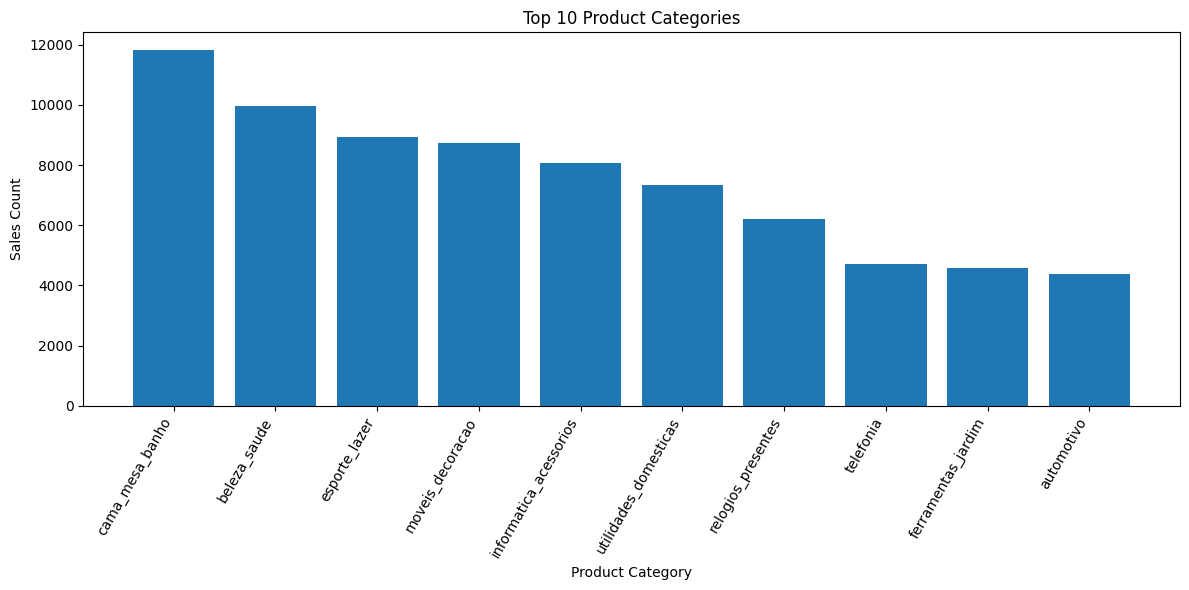

In [152]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(top_products["product_category_name"],top_products["total_sales"])

plt.title("Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Sales Count")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.savefig("/content/top_product_categories.png",dpi=300, bbox_inches="tight")
plt.show()

## Visualization 2: Top States by Orders

In [153]:
top_states = spark.sql("""
SELECT
customer_state,
COUNT(*) AS total_orders
FROM olist
GROUP BY customer_state
ORDER BY total_orders DESC
LIMIT 10
""").toPandas()

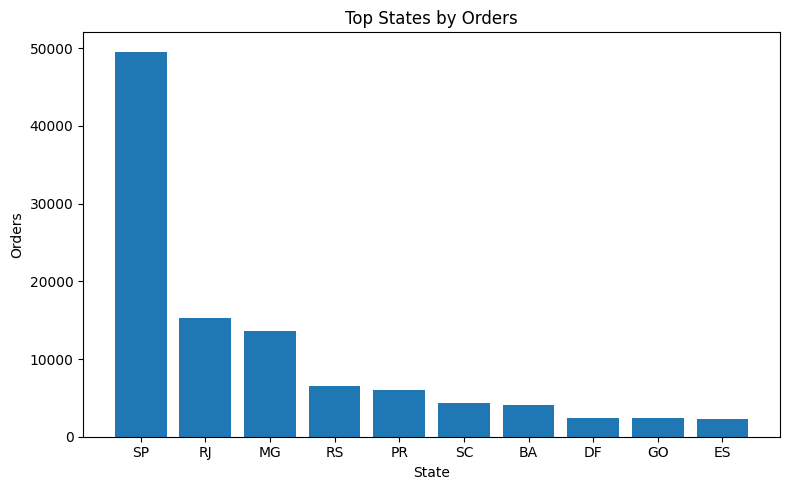

In [154]:
plt.figure(figsize=(8,5))
plt.bar(top_states["customer_state"],
        top_states["total_orders"])

plt.title("Top States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")

plt.tight_layout()
plt.savefig("/content/top_states_orders.png",dpi=300,bbox_inches="tight")
plt.show()

In [155]:
final_df.write.mode("overwrite").parquet("olist_integrated_parquet")

print("Integrated dataset saved successfully.")

Integrated dataset saved successfully.


In [156]:
display(final_df.limit(5))

DataFrame[product_id: string, order_id: string, customer_id: string, order_status: string, order_purchase_timestamp: timestamp, order_approved_at: timestamp, order_delivered_carrier_date: timestamp, order_delivered_customer_date: timestamp, order_estimated_delivery_date: timestamp, customer_unique_id: string, customer_zip_code_prefix: int, customer_city: string, customer_state: string, order_item_id: int, seller_id: string, shipping_limit_date: timestamp, price: double, freight_value: double, payment_sequential: int, payment_type: string, payment_installments: int, payment_value: double, product_category_name: string, product_name_lenght: int, product_description_lenght: int, product_photos_qty: int, product_weight_g: int, product_length_cm: int, product_height_cm: int, product_width_cm: int]

In [157]:
final_df.show(5, truncate=False)

+--------------------------------+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------------------+------------------------+---------------+--------------+-------------+--------------------------------+-------------------+-----+-------------+------------------+------------+--------------------+-------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|customer_unique_id              |customer_zip_code_prefix|customer_city  |customer_state|order_item_id|s

# 11. Conclusion

Finally, This project successfully demonstrated a complete data integration workflow using Apache Spark. Multiple datasets from the Brazilian Olist e-commerce platform were loaded, explored, cleaned, integrated and stored in Parquet format.

Therefore, Spark SQL was used to generate business insights regarding product categories, customer locations and payment methods. The analysis revealed that home-related products were the most frequently purchased categories, São Paulo generated the highest number of orders, and credit cards were the dominant payment method.

Futheremore ,the project demonstrates the use of distributed data processing techniques and highlights how Apache Spark can support scalable data integration and analytical workflows.

In [158]:
from google.colab import files

files.download('/content/top_product_categories.png')
files.download('/content/top_states_orders.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>